In [2]:
import scipy
import functools
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import importlib
from datasets import Dataset, Audio, Features, Value, Sequence, load_from_disk, concatenate_datasets
from sklearn.metrics import f1_score
from scipy.stats import ttest_rel
from scipy.stats import ttest_ind 

In [ ]:
#####################################################################################################################

######################################## DATA PREP ##################################################################

#####################################################################################################################

In [ ]:
#CREATE WOZ PRED DF
woz_ds = load_from_disk(r"data\predictions-cp75\woz_preds")
woz_ds.remove_columns(["input_values", "audio"])
woz = woz_ds.to_pandas(woz_ds)
woz['phq8_pred'] = woz['prediction'] * 24
woz_phq_pred_mean = woz['phq8_pred'].mean()
woz_phq_pred_std = woz['phq8_pred'].std()
woz['phq8_z'] = (woz['phq8_pred'] - woz_phq_pred_mean) / woz_phq_pred_std

In [4]:
#OBTAIN DF OF MEAN PREDICTIONS FOR TEST SET
test_mean = (
    test.groupby("participant")[["phq_score", "phq8_pred"]]
    .mean()
    .reset_index()
)
test_mean["gender"] = test_mean["participant"].map(dict(zip(test["participant"], test["gender"])))
test_mean.to_pickle("test_mean_cp75.pkl")

In [9]:
#OR LOAD
test_mean = pd.read_pickle("test_mean.pkl")

In [4]:
#LOAD ACTUAL PHQ SCORES
pre = pd.read_pickle(r"data\pickles\pre_phq.pkl")
post = pd.read_pickle(r"data\pickles\post_phq.pkl")
#OBTAIN SIDE-BY-SIDE OF ACTUAL PHQ PER LAB VISIT
actual = pre[["pre_ID", "phq8"]].merge(
    post[["post2_ID", "phq8"]],
    left_on="pre_ID",
    right_on="post2_ID",
    suffixes=("_pre", "_post")
).drop(columns="post2_ID")
actual.columns = ["participant", "pre", "post"]

In [5]:
#CREATE CONDITION MAPPING AND CHECK IF EQUAL BETWEEN PRE AND POST
participant_to_group = dict(zip(pre["pre_ID"], pre["group"]))
participant_to_group2 = dict(zip(post["post2_ID"], post["group"]))
print(participant_to_group == participant_to_group2)
print(pre["pre_ID"].dtype, post["post2_ID"].dtype)
print(set(pre["pre_ID"]) - set(post["post2_ID"]))  # in pre maar niet in post
print(set(post["post2_ID"]) - set(pre["pre_ID"]))  # in post maar niet in pre

False
int64 int64
{58, 59, 36}
set()


In [6]:
#ADD CONDITION COLUMN TO ACTUAL PHQ SCORES DF
actual["mfl"] = actual["participant"].map(participant_to_group)

In [ ]:
#CREATE MIC PRED DF
mic_ds = load_from_disk(r"C:\Users\`\mt\temp_download\final_model\mic_preds_final.parquet")
mic_ds.remove_columns(["input_values", "audio"])
mic = mic_ds.to_pandas(mic_ds)
mic["phq8_pred"] = mic['prediction'] * 24
mic.to_pickle("mic.pkl")
mic_phq_pred_mean = mic['phq8_pred'].mean()
mic_phq_pred_std = mic['phq8_pred'].std()
mic['phq8_z'] = (mic['phq8_pred'] - mic_phq_pred_mean) / mic_phq_pred_std

In [18]:
mic

,participant,question_number,t,segment_number,audio,long_enough,input_values,prediction,phq8_pred,phq8_z
0,25,3,0,0,{'bytes': b'RIFFF\xc4\t\x00WAVEfmt \x10\x00\x0...,True,"[-0.0004491638, -0.0004491638, -0.0004491638, ...",0.295575,7.093804,-0.758532
1,25,2,0,0,{'bytes': b'RIFFF\xc4\t\x00WAVEfmt \x10\x00\x0...,True,"[-0.0004491638, -0.0004491638, -0.0004491638, ...",0.314625,7.550994,-0.155048
2,25,3,1,0,{'bytes': b'RIFFF\xc4\t\x00WAVEfmt \x10\x00\x0...,True,"[-0.0004491638, -0.0004491638, -0.0004491638, ...",0.274488,6.587701,-1.426580
3,25,3,1,1,{'bytes': b'RIFFF\xc4\t\x00WAVEfmt \x10\x00\x0...,True,"[0.386392, 0.37870133, 0.3694725, 0.3456314, 0...",0.303471,7.283297,-0.508405
4,25,4,0,0,{'bytes': b'RIFFF\xc4\t\x00WAVEfmt \x10\x00\x0...,True,"[-0.0004491638, -0.0004491638, -0.0004491638, ...",0.288372,6.920940,-0.986711
...,...,...,...,...,...,...,...,...,...,...
685,31,3,0,2,{'bytes': b'RIFFF\xc4\t\x00WAVEfmt \x10\x00\x0...,True,"[0.21450531, 0.19873942, 0.17720553, 0.1475964...",0.333488,8.003720,0.442543
686,31,2,0,0,{'bytes': b'RIFFF\xc4\t\x00WAVEfmt \x10\x00\x0...,True,"[-0.0004491638, -0.0004491638, -0.0004491638, ...",0.325615,7.814772,0.193135
687,31,2,0,1,{'bytes': b'RIFFF\xc4\t\x00WAVEfmt \x10\x00\x0...,True,"[0.10914302, 0.12990786, 0.1575943, 0.17182206...",0.305065,7.321566,-0.457890
688,31,2,0,2,{'bytes': b'RIFFF\xc4\t\x00WAVEfmt \x10\x00\x0...,True,"[0.0037807096, -0.0046790377, -0.04966951, -0....",0.311341,7.472178,-0.259084


In [19]:
mic.columns

Index(['participant', 'question_number', 't', 'segment_number', 'audio',
       'long_enough', 'input_values', 'prediction', 'phq8_pred', 'phq8_z'],
      dtype='str')

In [10]:
#CREATE DF OF MEAN MIC PREDICTIONS
mic_mean = mic.groupby(["participant", "t"])[["phq8_pred", "phq8_z"]].mean().reset_index()
mic_mean_wide = mic_mean.pivot(index="participant", columns="t", values="phq8_pred")
mic_mean_wide.columns = ["interview_0_mu","interview_1_mu","interview_2_mu"]

In [11]:
#CREATE HOME PRED DF
home_ds = load_from_disk(r"data\predictions-cp75\home_preds")
home_ds = home_ds.remove_columns(["input_values", "audio"])
home = home_ds.to_pandas(home_ds)
home["phq8_pred"] = home['prediction'] * 24
home_phq_pred_mean = home['phq8_pred'].mean()
home_phq_pred_std = home['phq8_pred'].std()
home['phq8_z'] = (home['phq8_pred'] - home_phq_pred_mean) / home_phq_pred_std

In [13]:
#CREATE DF OF MEAN HOME PREDICTIONS
home_mean = home.groupby(["participant", "day"])[["phq8_pred", "phq8_z"]].mean().reset_index()
home_mean_wide = home_mean.pivot(index="participant", columns="day", values="phq8_pred")
day_mean_column_names = [f"day_{i}_mu" for i in range(1, 15)]
home_mean_wide.columns = day_mean_column_names

In [14]:
#COMBINE SEPARATE DATAFRAMES INTO ONE
dfs = [home_mean_wide, mic_mean_wide, actual]
df = functools.reduce(lambda left, right: pd.merge(left, right, on="participant", how="outer"), dfs)
df['mfl'] = (df['mfl']).astype(bool)

In [15]:
#CALCULATE PRE TO POST DIFF AND SLOPES
# COMPUTE SLOPE COEFFICIENTS FOR REGRESSION LINE EXPLAINING PHQ8_PRED OVER TIME
df["post-pre"] = df['post'] - df['pre']
df["slope_mu"] = df[day_mean_column_names].apply(lambda row: np.polyfit(np.arange(len(row.dropna())), row.dropna(), 1)[0], axis=1)
df.to_pickle("df.pkl")

In [34]:
#OR LOAD 
df = pd.read_pickle("df.pkl")

In [ ]:
#####################################################################################################################

################################# LEGACY PLOTS ######################################################################

#####################################################################################################################

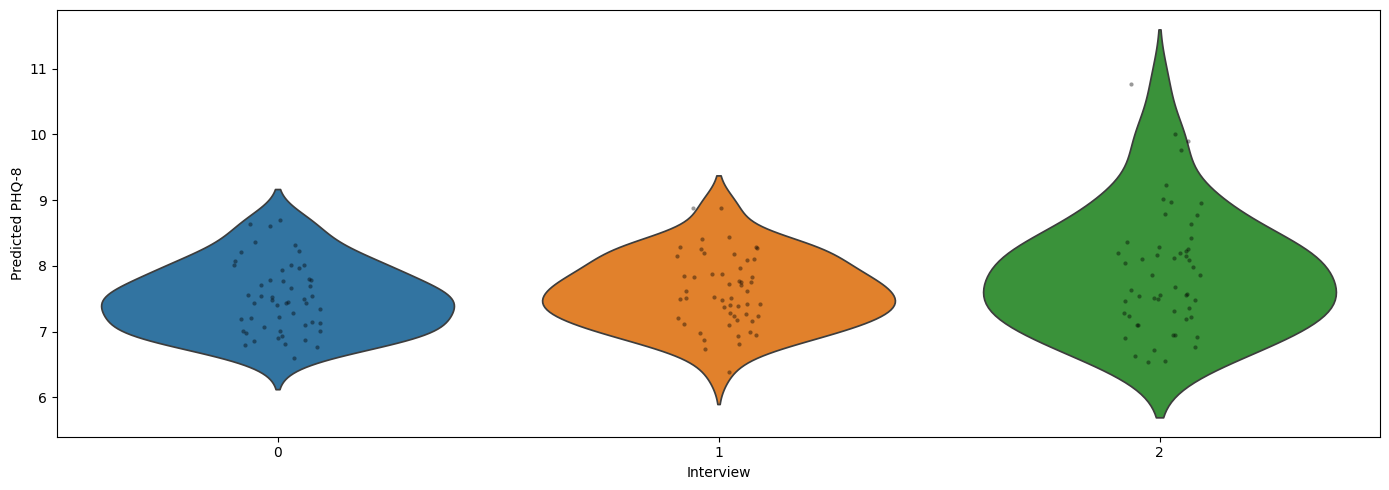

In [16]:
#PLOT MEAN MIC PRED PHQ DISTRIBUTIONS
fig, ax = plt.subplots(figsize=(14, 5))
sns.violinplot(data=mic_mean_wide[[f"interview_{i}_mu" for i in range(3)]], ax=ax, inner=None)
sns.stripplot(data=mic_mean_wide[[f"interview_{i}_mu" for i in range(3)]], ax=ax, alpha=0.4, color="black", size=3)
ax.set_xticks(range(3))
ax.set_xticklabels(range(3))
ax.set_xlabel("Interview")
ax.set_ylabel("Predicted PHQ-8")
plt.tight_layout()
plt.show()

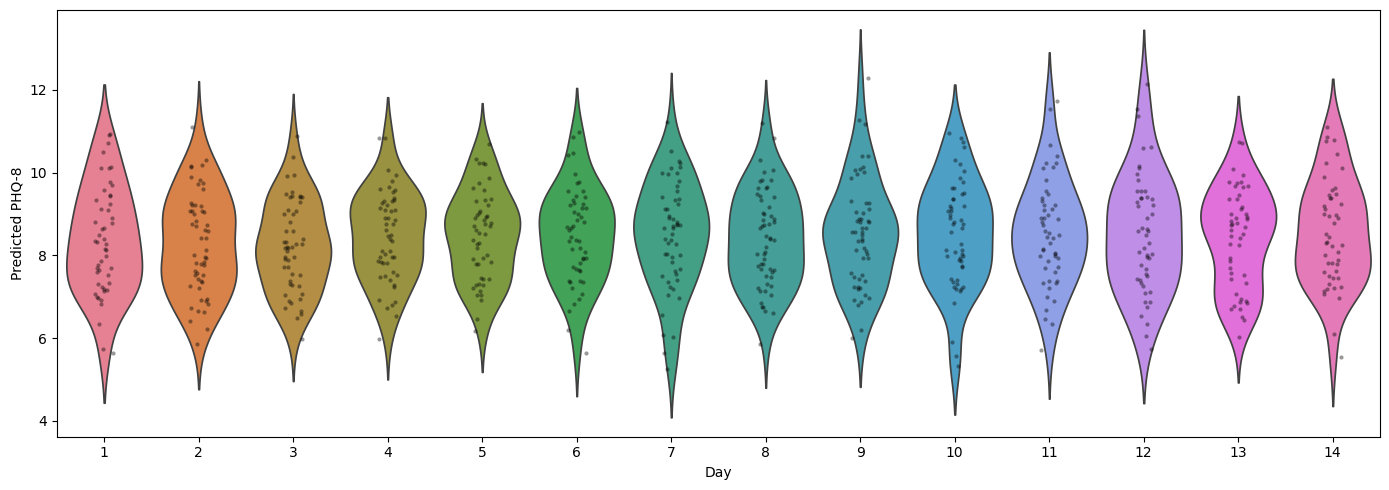

In [17]:
#PLOT MEAN HOME PRED PHQ DISTRIBUTIONS
fig, ax = plt.subplots(figsize=(14, 5))
sns.violinplot(data=home_mean_wide[[f"day_{i}_mu" for i in range(1, 15)]], ax=ax, inner=None)
sns.stripplot(data=home_mean_wide[[f"day_{i}_mu" for i in range(1, 15)]], ax=ax, alpha=0.4, color="black", size=3)
ax.set_xticks(range(14))
ax.set_xticklabels(range(1, 15))
ax.set_xlabel("Day")
ax.set_ylabel("Predicted PHQ-8")
plt.tight_layout()
plt.show()

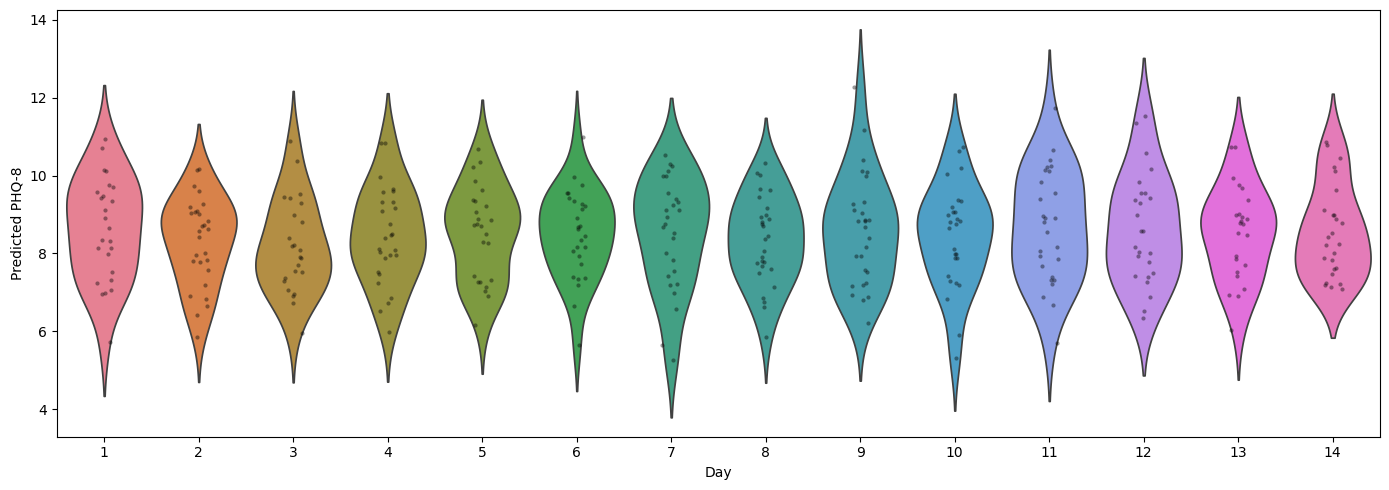

In [18]:
#SEPARATE BY CONDITION
subset = df[df["mfl"] == True]
day_cols_mu = [f"day_{i}_mu" for i in range(1, 15)]

fig, ax = plt.subplots(figsize=(14, 5))
sns.violinplot(data=subset[day_cols_mu], ax=ax, inner=None)
sns.stripplot(data=subset[day_cols_mu], ax=ax, alpha=0.4, color="black", size=3)
ax.set_xticks(range(14))
ax.set_xticklabels(range(1, 15))
ax.set_xlabel("Day")
ax.set_ylabel("Predicted PHQ-8")
#ax.set_title(f"Group: {'MFL' if group else 'Control'}")
plt.tight_layout()
plt.show()

In [95]:
df.columns

Index(['participant', 'day_1', 'day_2', 'day_3', 'day_4', 'day_5', 'day_6',
       'day_7', 'day_8', 'day_9', 'day_10', 'day_11', 'day_12', 'day_13',
       'day_14', 'day_1_mu', 'day_2_mu', 'day_3_mu', 'day_4_mu', 'day_5_mu',
       'day_6_mu', 'day_7_mu', 'day_8_mu', 'day_9_mu', 'day_10_mu',
       'day_11_mu', 'day_12_mu', 'day_13_mu', 'day_14_mu', 'interview_0',
       'interview_1', 'interview_2', 'interview_0_mu', 'interview_1_mu',
       'interview_2_mu', 'pre', 'post', 'mfl', 'post-pre', 'slope_mu',
       'slope_extr'],
      dtype='object')

In [ ]:
#####################################################################################################################

################################## LEGACY STATISTICS #################################################################

#####################################################################################################################

In [35]:
#ANALYSIS: IS GENDER EXPLANATION FOR THE DISCREPANCY?
print(woz.groupby(["gender", "split"])["phq_score"].mean())
print(woz[woz["split"] == "test"].groupby("gender")["phq8_pred"].mean())
test_mean["gender"] = test_mean["participant"].map(dict(zip(woz["participant"], woz["gender"])))
test_mean["gender_bin"] = (test_mean["gender"] == "feminine").astype(int)
r, p = pointbiserialr(test_mean["gender_bin"], test_mean["phq_score"])
print(f"gender-PHQ r = {r:.3f}, p = {p:.3f}")
r, p = pointbiserialr(test_mean["gender_bin"], test_mean["phq8_pred"])
print(f"gender-pred r = {r:.3f}, p = {p:.3f}")
print(f"R squared for gender in PHQ predicitons = {r**2*100:.1f}%")

gender     split
feminine   dev      8.641169
           test     7.009595
           train    7.210526
masculine  dev      8.880540
           test     6.852257
           train    5.813763
Name: phq_score, dtype: float32
gender
feminine     8.964367
masculine    7.158447
Name: phq8_pred, dtype: float64
gender-PHQ r = 0.010, p = 0.947
gender-pred r = 0.382, p = 0.008
R squared for gender in PHQ predicitons = 14.6%


In [15]:
test_mean["gender_bin"] = (test_mean["gender"] == "feminine").astype(int)
result = partial_corr(data=test_mean, x="phq_score", y="phq8_pred", covar="gender_bin")
print(result)

          n         r          CI95    p_val
pearson  47  0.489851  [0.23, 0.68]  0.00055


In [ ]:
#TEST DIFF IN PREDICTIONS
mew = mic_mean_wide[["interview_0", "interview_2"]].dropna()
t, p = ttest_rel(mew["interview_0"], mew["interview_2"])
p

In [ ]:
full_mic = combined_preds.merge(combined, left_on="participant", right_on="pre_ID", how="outer")

In [ ]:
#CALCULATE SETS OF PARTRICIPANTS FOR WHOM PREDICTED PHQ IS PRESENT FOR FIRST LAB (t1) AND FOLLOW-UP (t2)
t1_present = {int(p) for p in mmp[(mmp["t"] == 0) | (mmp["t"] == 1)]["participant"].unique()}
t2_present = {int(p) for p in mmp[mmp["t"] == 2]["participant"].unique()}
# ((P U Q) / P) U ((P U Q) / Q) = (Q / P) U (P / Q) = P Δ Q
at_least_1_missing = t1_present ^ t2_present
at_least_1_missing

In [ ]:
#MERGE PRED FROM LAB AND PRED FROM HOME
combined_preds = mmp_wide.merge(hmp_wide, on="participant", how="outer")

In [ ]:
full_phq = combined_preds.merge(combined, left_on="participant", right_on="pre_ID", how="outer")

In [ ]:
full_phq.columns

In [ ]:
#COMPUTE R FOR PHQ REAL AND PREDICTED AT FOLLOW-UP
compare = full_phq[['phq8_post', 'phq8_pred_t2']].dropna()
scipy.stats.pearsonr(compare['phq8_post'], compare['phq8_pred_t2'])

In [ ]:
#COMPUTE R FOR PHQ REAL AND PREDICTED AT FIRST VISIT
full_phq["phq8_pred_t0t1_mean"] = full_phq[["phq8_pred_t0", "phq8_pred_t1"]].mean(axis=1)
compare = full_phq[['phq8_pre', 'phq8_pred_t0t1_mean']].dropna()
scipy.stats.pearsonr(compare['phq8_pre'], compare['phq8_pred_t0t1_mean'])

In [ ]:
#COMPUTE R BETWEEN SLOPE COEFFICIENTS AND REAL PHQ DIFFERENCES BETWEEN PRE AND POST
compare = full_phq[['slope', 'phq8_prepostdiff']].dropna()
scipy.stats.pearsonr(compare['slope'], compare['phq8_prepostdiff'])

In [ ]:
full_phq.to_pickle("full_phq.pkl")

In [ ]:
full_phq.columns

In [ ]:
full_phq = pd.read_pickle("full_phq.pkl")

In [ ]:
q = compare['phq8_prepostdiff'] > 0      # true improvement
q_hat = compare['slope'] < 0             # predicted improvement (slope going down = improving)

print(f1_score(q, q_hat))

In [ ]:
print(q.value_counts())

In [ ]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(compare[['phq8_prepostdiff']], q)
dummy_pred = dummy.predict(compare[['phq8_prepostdiff']])
print(f"Dummy F1: {f1_score(q, dummy_pred):.3f}")

dummy_random = DummyClassifier(strategy='stratified')
dummy_random.fit(compare[['phq8_prepostdiff']], q)
dummy_pred_random = dummy_random.predict(compare[['phq8_prepostdiff']])
print(f"Random F1: {f1_score(q, dummy_pred_random):.3f}")